In [1]:
import re
import ftfy
import shap
import torch
import unicodedata
import numpy as np
import matplotlib.pyplot as plt

import torch.nn.functional as F

from transformers import (
    AutoTokenizer,
    AutoModelForSequenceClassification
)

In [2]:
device = torch.device(
    "cuda" if torch.cuda.is_available() else "cpu"
)

print("Device :", device)

if torch.cuda.is_available():
    print(torch.cuda.get_device_name(0))

Device : cuda
NVIDIA GeForce RTX 3060 Ti


In [3]:
MODEL_PATH = "../model/indobert_best"

tokenizer = AutoTokenizer.from_pretrained(MODEL_PATH)

model = AutoModelForSequenceClassification.from_pretrained(
    MODEL_PATH
)

model.to(device)

model.eval()

print("Model berhasil dimuat.")

Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

Model berhasil dimuat.


In [4]:
# =====================================================
# PREPROCESSING
# =====================================================

mapping = {

    "А":"A","В":"B","Е":"E","К":"K","М":"M","Н":"H",
    "О":"O","Р":"P","С":"C","Т":"T","Х":"X","У":"Y",

    "а":"a","е":"e","о":"o","р":"p","с":"c",
    "х":"x","у":"y","к":"k","м":"m","н":"h",

    "Α":"A","Β":"B","Ε":"E","Η":"H",
    "Ι":"I","Κ":"K","Μ":"M","Ν":"N",
    "Ο":"O","Ρ":"P","Τ":"T","Χ":"X"

}

TRANSLATE_TABLE = str.maketrans(mapping)

HTML_RE = re.compile(r"<.*?>")
URL_RE = re.compile(r"http\S+")
WWW_RE = re.compile(r"www\S+")
MENTION_RE = re.compile(r"@\w+")
EMOJI_RE = re.compile(r"[\U00010000-\U0010ffff]", flags=re.UNICODE)
SPECIAL_RE = re.compile(r"[^A-Za-z0-9\s]")
SPACE_RE = re.compile(r"\s+")


def preprocess(text):

    text = str(text)

    # Unicode Normalize
    text = ftfy.fix_text(text)
    text = unicodedata.normalize("NFKC", text)
    text = text.translate(TRANSLATE_TABLE)

    # Cleaning
    text = HTML_RE.sub(" ", text)
    text = URL_RE.sub(" ", text)
    text = WWW_RE.sub(" ", text)
    text = MENTION_RE.sub(" ", text)
    text = EMOJI_RE.sub(" ", text)
    text = SPECIAL_RE.sub(" ", text)

    # Case Folding
    text = text.lower()

    # Hapus spasi berlebih
    text = SPACE_RE.sub(" ", text)

    return text.strip()

In [5]:
import torch.nn.functional as F

MAX_LENGTH = 128

def predict_proba(texts):

    texts = [preprocess(t) for t in texts]

    inputs = tokenizer(
        texts,
        padding=True,
        truncation=True,
        max_length=MAX_LENGTH,
        return_tensors="pt"
    )

    inputs = {
        k: v.to(device)
        for k, v in inputs.items()
    }

    with torch.no_grad():

        outputs = model(**inputs)

        probs = F.softmax(outputs.logits, dim=1)

    return probs.cpu().numpy()

In [6]:
explainer = shap.Explainer(
    predict_proba,
    tokenizer
)

print(explainer)

shap.explainers.PartitionExplainer()


In [7]:
text = "bonus new member slot gacor terpercaya"

print(text)

bonus new member slot gacor terpercaya


In [8]:
shap_values = explainer([text])

In [9]:
print(shap_values.shape)

(1, 8, 2)


In [10]:
shap.plots.text(shap_values[0])

In [11]:
import torch.nn.functional as F

inputs = tokenizer(
    preprocess(text),
    return_tensors="pt",
    truncation=True,
    padding=True,
    max_length=128
)

inputs = {
    k: v.to(device)
    for k, v in inputs.items()
}

with torch.no_grad():

    outputs = model(**inputs)

    probs = F.softmax(outputs.logits, dim=1)

pred = torch.argmax(probs).item()

labels = {
    0: "Bukan Judi Online",
    1: "Judi Online"
}

print("Prediksi :", labels[pred])
print("Probabilitas :", probs.cpu().numpy())

Prediksi : Judi Online
Probabilitas : [[0.01844371 0.9815563 ]]


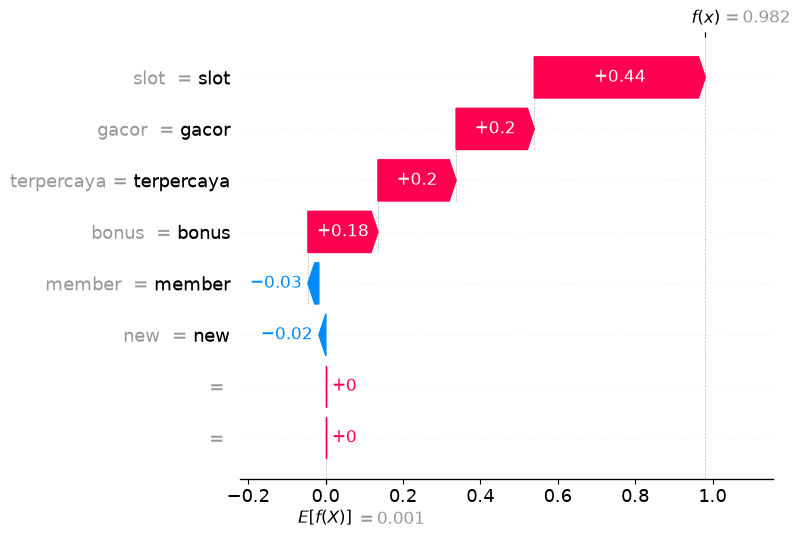

Waterfall plot berhasil disimpan.


In [12]:
plt.figure(figsize=(8, 6))

shap.plots.waterfall(
    shap_values[0, :, 1],
    show=False
)

plt.tight_layout()
plt.savefig(
    "../output/shap_waterfall_plot.png",
    dpi=300,
    bbox_inches="tight"
)
plt.show()

print("Waterfall plot berhasil disimpan.")

<Figure size 1400x300 with 0 Axes>

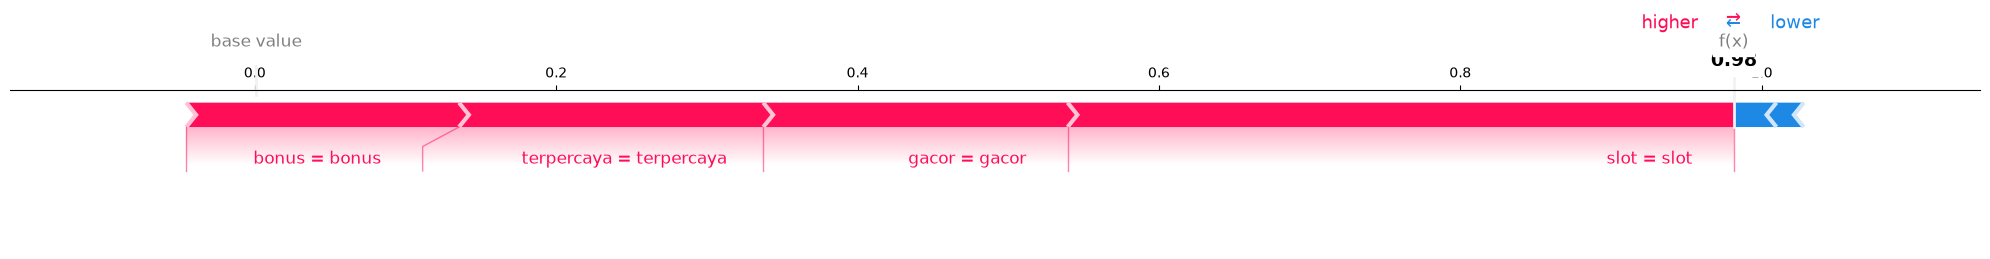

Force plot berhasil disimpan (PNG & HTML).


In [13]:
# =====================================================
# FORCE PLOT
# =====================================================

plt.figure(figsize=(14, 3))

shap.plots.force(
    shap_values[0, :, 1],
    matplotlib=True,
    show=False
)

plt.tight_layout()
plt.savefig(
    "../output/shap_force_plot.png",
    dpi=300,
    bbox_inches="tight"
)
plt.show()

force_vis = shap.plots.force(
    shap_values[0, :, 1],
    matplotlib=False,
    show=False
)

shap.save_html(
    "../output/shap_force_plot.html",
    force_vis
)

print("Force plot berhasil disimpan (PNG & HTML).")

In [14]:
import pandas as pd

from sklearn.model_selection import train_test_split

DATASET_PATH = "../output/dataset_preprocessing.csv"

df = pd.read_csv(DATASET_PATH)

train_df, temp_df = train_test_split(
    df,
    test_size=0.20,
    random_state=42,
    stratify=df["label"]
)

valid_df, test_df = train_test_split(
    temp_df,
    test_size=0.50,
    random_state=42,
    stratify=temp_df["label"]
)

print("Train :", len(train_df))
print("Valid :", len(valid_df))
print("Test  :", len(test_df))

Train : 16645
Valid : 2081
Test  : 2081


In [15]:
texts = test_df["hasil_preprocessing"].sample(
    n=100,
    random_state=42
).tolist()

values = explainer(texts)

PartitionExplainer explainer:  21%|██        | 21/100 [00:00<?, ?it/s]

PartitionExplainer explainer:  23%|██▎       | 23/100 [00:11<00:35,  2.18it/s]

PartitionExplainer explainer:  24%|██▍       | 24/100 [00:11<00:28,  2.65it/s]

PartitionExplainer explainer:  25%|██▌       | 25/100 [00:12<00:30,  2.47it/s]

PartitionExplainer explainer:  26%|██▌       | 26/100 [00:12<00:31,  2.36it/s]

...

PartitionExplainer explainer:  98%|█████████▊| 98/100 [00:46<00:00,  2.68it/s]

PartitionExplainer explainer:  99%|█████████▉| 99/100 [00:46<00:00,  2.12it/s]

PartitionExplainer explainer: 100%|██████████| 100/100 [00:46<00:00,  2.64it/s]

PartitionExplainer explainer: 101it [00:47,  2.96it/s]                         

PartitionExplainer explainer: 101it [00:47,  1.70it/s]

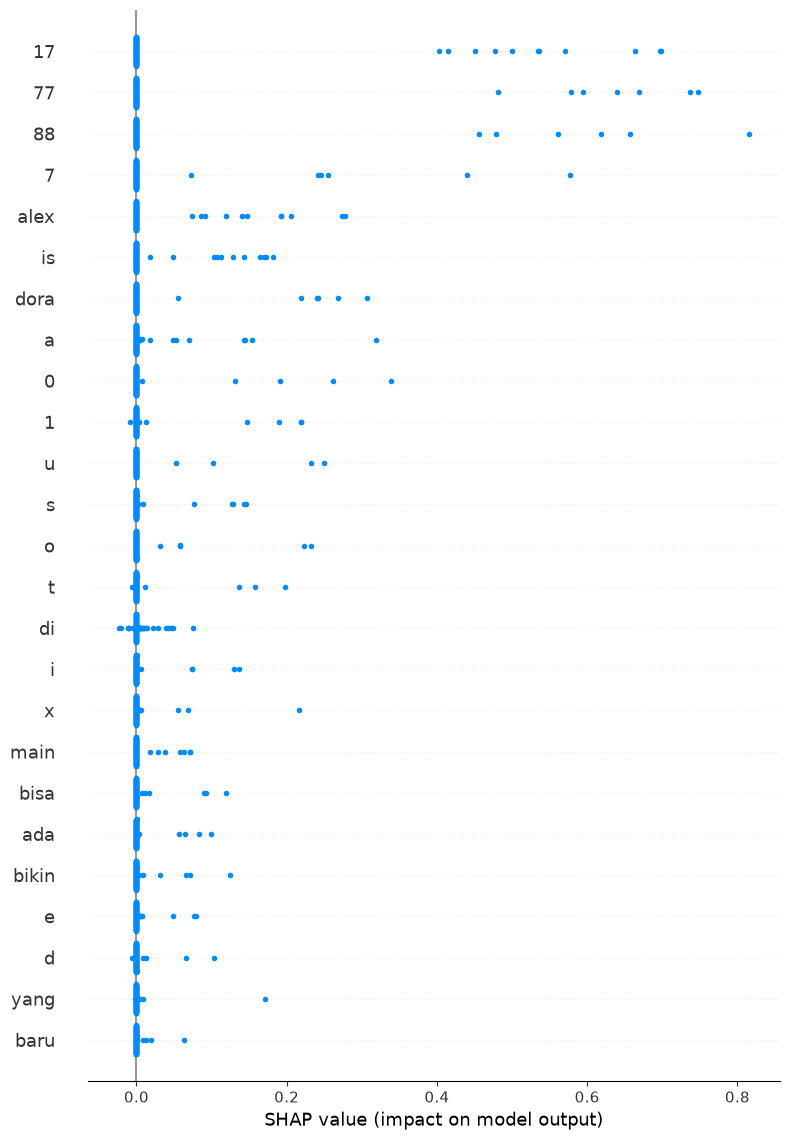

Summary plot berhasil disimpan.


In [16]:
# =====================================================
# SUMMARY PLOT (100 sampel uji, kelas Judi Online)
# =====================================================

import numpy as np

from collections import Counter

token_count = Counter()

for sample in values:
    token_count.update(
        str(token).strip()
        for token in sample.data
        if str(token).strip()
    )

top_tokens = [
    token
    for token, _ in token_count.most_common(40)
]

token_index = {
    token: i
    for i, token in enumerate(top_tokens)
}

shap_matrix = np.zeros(
    (len(values), len(top_tokens))
)

for i, sample in enumerate(values):

    tokens = [
        str(token).strip()
        for token in sample.data
    ]

    scores = sample.values[:, 1]

    for token, score in zip(tokens, scores):

        if token in token_index:

            shap_matrix[i, token_index[token]] += score

plt.figure(figsize=(10, 8))

shap.summary_plot(
    shap_matrix,
    feature_names=top_tokens,
    max_display=25,
    show=False
)

plt.tight_layout()
plt.savefig(
    "../output/shap_summary_plot.png",
    dpi=300,
    bbox_inches="tight"
)
plt.show()

print("Summary plot berhasil disimpan.")

In [17]:
from collections import defaultdict
import pandas as pd

token_scores = defaultdict(list)

for sample in values:

    tokens = sample.data

    shap_scores = sample.values[:, 1]

    for token, score in zip(tokens, shap_scores):

        token = token.strip()

        if token == "":
            continue

        token_scores[token].append(abs(score))

In [18]:
importance = []

for token, scores in token_scores.items():

    importance.append({

        "Token": token,

        "Mean_SHAP": sum(scores) / len(scores),

        "Frequency": len(scores)

    })

importance = pd.DataFrame(importance)

importance = importance.sort_values(

    by="Mean_SHAP",

    ascending=False

)

importance.head(20)

,Token,Mean_SHAP,Frequency
356,777,0.678175,3
30,77,0.635526,7
241,88,0.597585,6
7,agust,0.590255,3
59,17,0.540308,11
102,99,0.433652,2
398,69,0.429202,1
724,xy,0.336593,1
192,4,0.320537,4
8,oto,0.315165,3


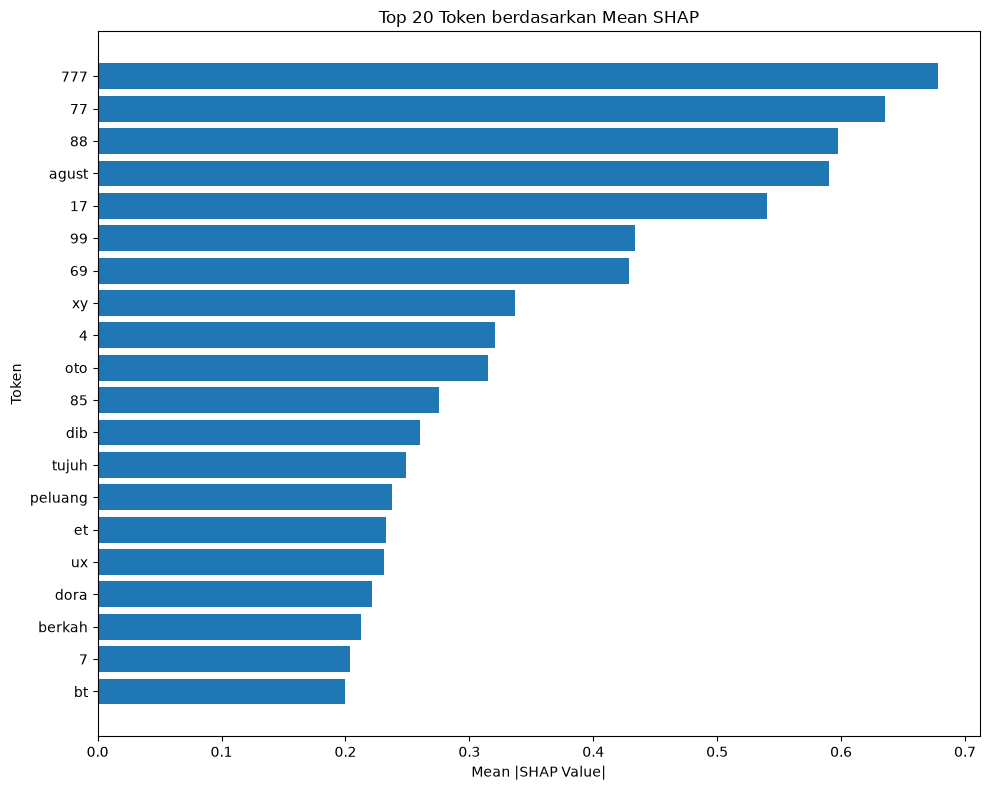

In [19]:
import matplotlib.pyplot as plt

top20 = importance.head(20)

plt.figure(figsize=(10,8))

plt.barh(

    top20["Token"],

    top20["Mean_SHAP"]

)

plt.gca().invert_yaxis()

plt.xlabel("Mean |SHAP Value|")

plt.ylabel("Token")

plt.title("Top 20 Token berdasarkan Mean SHAP")

plt.tight_layout()

plt.savefig(

    "../output/shap_global_importance.png",

    dpi=300,

    bbox_inches="tight"

)

plt.show()

In [20]:
importance.to_csv(

    "../output/shap_global_importance.csv",

    index=False,

    encoding="utf-8-sig"

)

print("Berhasil disimpan.")

Berhasil disimpan.


In [21]:
shap.plots.text(values[0])

In [22]:
shap.plots.text(values[1])